In [2]:
from src.utils import get_path, set_device, find_closest_power_of_2, get_diffusion_schedule_nickname
from src.QDDPM_torch_angel import WassDistance
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from tqdm import tqdm
import yaml
from pathlib import Path

# Actually read the config
modeldir = Path('results_MLP/CLUSTER0_1/modelresults_linear-slope1.3_N200_M2_n1_T20')
with open(modeldir/'config.yaml') as f:
    config = yaml.safe_load(f)

n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits # config['dataset']['transforms']['resize']**2

n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
diffusion_schedule = get_diffusion_schedule_nickname(config)
_, n_qubits = find_closest_power_of_2(n_features, return_power=True)

seed = config['seed']
device = set_device(config.get('device', 'cpu'))
torch.set_default_device(device)
get_path_partial = partial(get_path, config, modeltype='UNet', diffusion_schedule_nickname=diffusion_schedule, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
n_limit=0

Using device: cuda:0


In [4]:
# Load the model
from train_UNET import MLP
model = MLP(
    input_dim=config['model']['input_dim'],
    n_hidden_layers=config['model']['n_hidden_layers'],
    hidden_dim=config['model']['hidden_dim'],
    output_dim=config['model']['output_dim']
)
checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
model.load_state_dict(model_weights)
model.to(device)
None

/tmp/ipykernel_1993045/2956681601.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)


In [45]:
# Compute Wasserstein distance across timesteps
from train_UNET import complex_to_interleaved_real, interleaved_real_to_complex
device_cpu = torch.device('cpu')
torch.set_default_device(device_cpu)

dir, filename = get_path_partial(type='diffusedqstates.npy')
states_diffused = np.load(dir/filename) # [T+1, n_data, n_features (complex)]
print(f"Diffused states shape: {states_diffused.shape}")

# Compute the Wasserstein Distance
wass = np.zeros(n_timesteps+1)
model.eval()
with torch.no_grad():
    targets_interleaved = complex_to_interleaved_real(torch.from_numpy(states_diffused).to(device)) # [T+1, n_data, n_features (real*2)]
    targets_interleaved = targets_interleaved.permute(1, 0, 2) # [n_data, T+1, n_features*2]
    inputs_last_timestep = targets_interleaved[:,-1, :] # [n_data, n_features*2]
        
    inputs_tplus1 = inputs_last_timestep
    inputs_tplus1.to(device)
    preds_ts = []
    for t in tqdm(range(n_timesteps, 0, -1)):
        if t < n_limit:
            continue
        t_tensor = torch.ones(inputs_tplus1.shape[0], dtype=torch.long, device=device) * t
        outputs = model(inputs_tplus1, t_tensor)
        pred = interleaved_real_to_complex(outputs) # [n_data, n_features] complex tensor
        norms = torch.linalg.norm(pred, dim=1, keepdim=True)
        pred = pred / norms

        preds_ts.append(pred.cpu().numpy())

        x1 = torch.from_numpy(states_diffused[0]).to(device_cpu)
        x2 = pred.to(device_cpu)
        # print(x1.device, x2.device)
        wass[t] = WassDistance(x1, x2).detach().cpu().numpy()
        inputs_tplus1 = outputs

preds_ts.append(interleaved_real_to_complex(inputs_last_timestep).cpu().numpy())
    
dir, filename = get_path_partial(type='wassdistbackwardtrain.npy')
np.save(dir / filename, wass)

# Now of the forward pass
# Wasserstein distance
wassf = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps, -1, -1)):
    if t < n_limit:
        continue
    np.random.seed()
    wassf[t] = WassDistance(torch.from_numpy(states_diffused[0]).to(device), torch.from_numpy(states_diffused[t]).to(device)).detach().cpu().numpy()

dir, filename = get_path_partial(type='wassdistforward.npy')
np.save(dir / filename, wassf)

Diffused states shape: (21, 200, 2)


100%|██████████| 21/21 [00:00<00:00, 253.27it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward and backward processes')

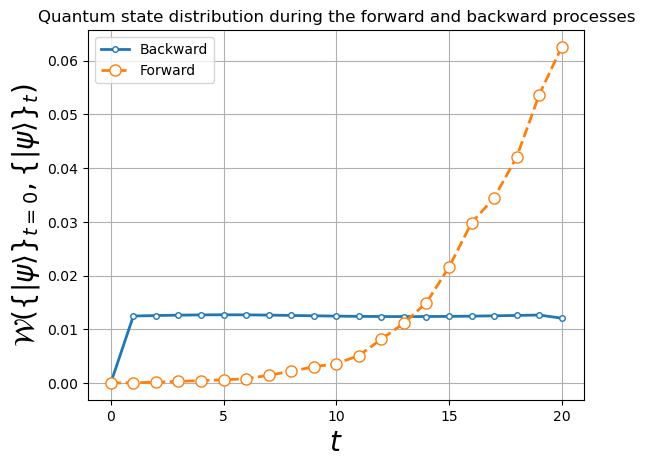

In [26]:
# Plot it

dir, filename = get_path_partial(type='wassdistforward.npy')
wassforward = np.load(dir / filename)
dir, filename = get_path_partial(type='wassdistbackwardtrain.npy')
wassbackwardtrain = np.load(dir / filename)

x = list(range(n_limit, n_timesteps+1))
plt.plot(x, wassbackwardtrain[n_limit:], 'o-', label=f'Backward', mfc='white', markersize=4, lw=2)
plt.plot(x, wassforward[n_limit:], 'o--', label='Forward', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.xticks(range(n_limit,n_timesteps+1, 5))
plt.grid(True)
plt.legend()
plt.title(f'Quantum state distribution during the forward and backward processes')

100%|██████████| 21/21 [00:08<00:00,  2.61it/s]


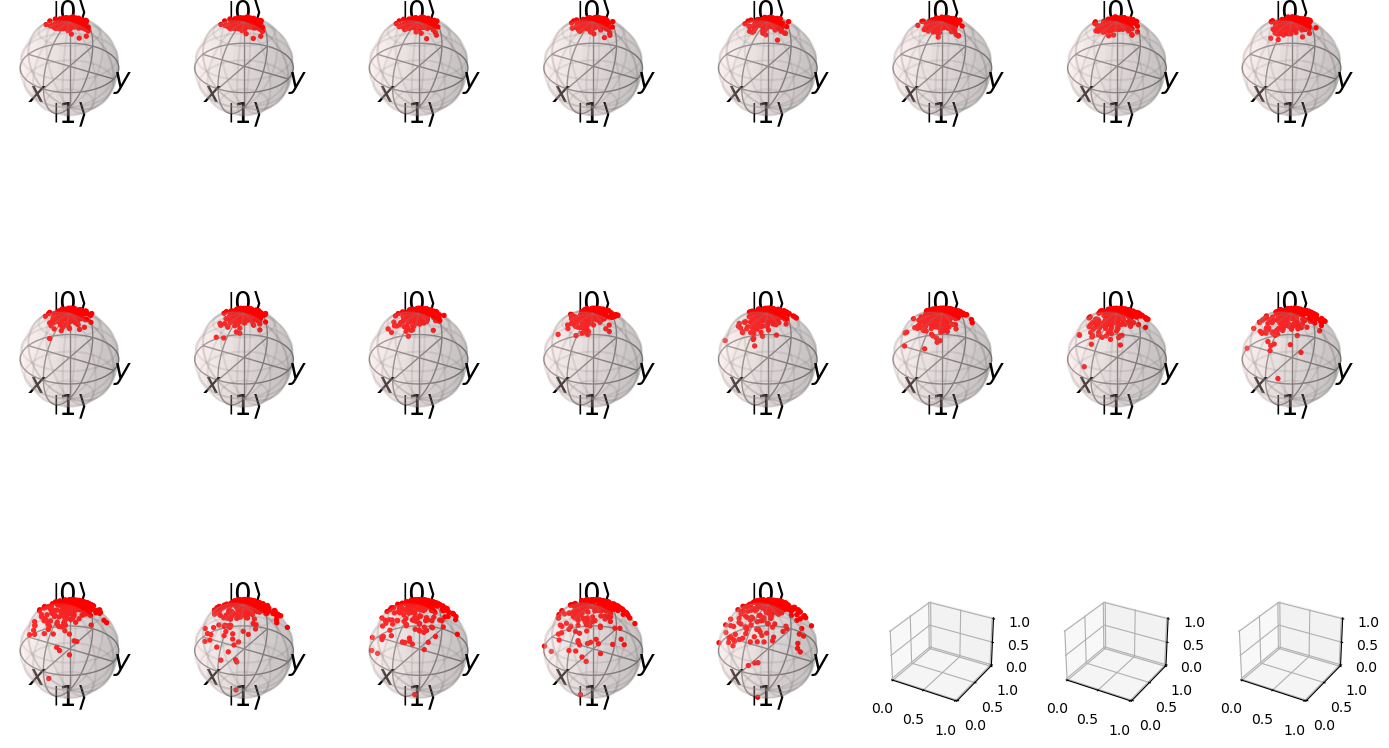

In [38]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

dir, filename = get_path_partial(type='diffusedqstates.npy')
diffused_states = np.load(dir / filename)

rows = 3
cols = 8
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(diffused_states[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['r']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

100%|██████████| 21/21 [00:08<00:00,  2.54it/s]


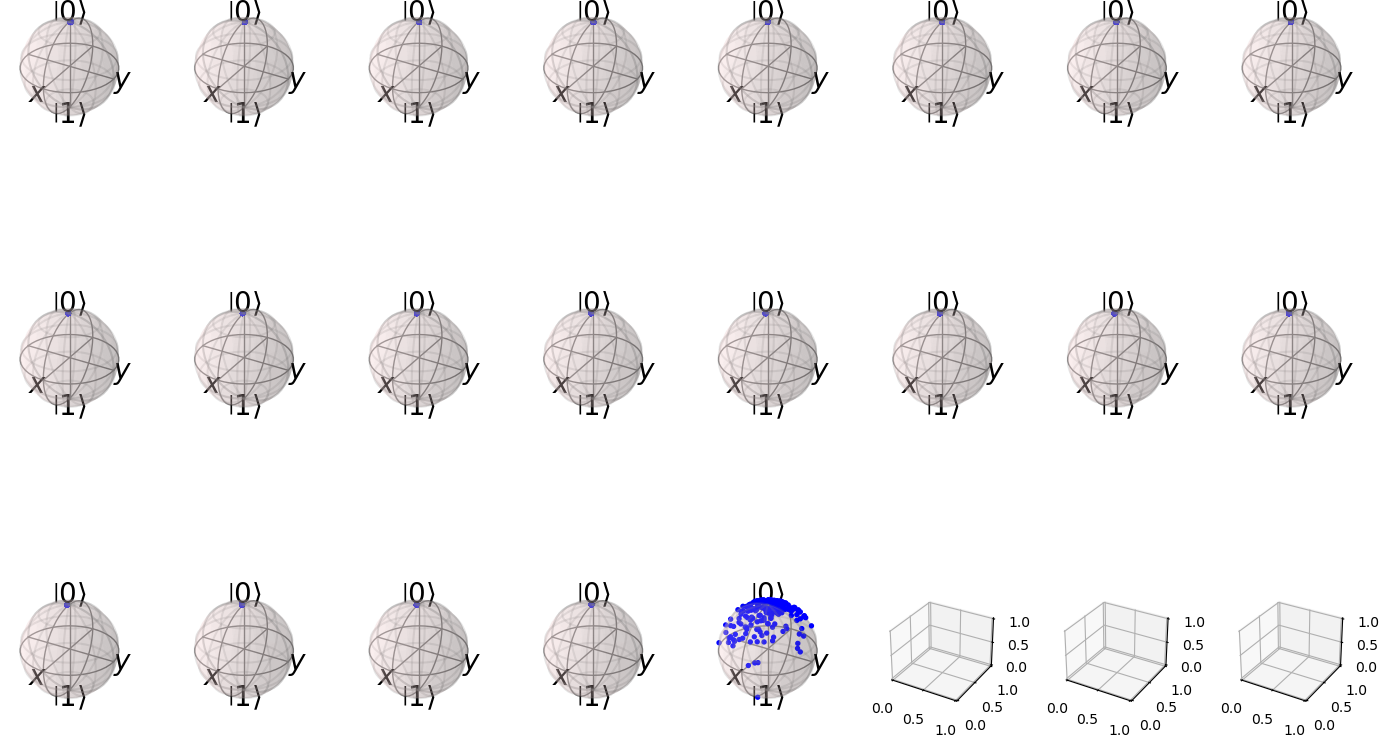

In [46]:
# Bloch visualize on the forward noise process
from opt_einsum import contract
import qutip as qt
from qutip import Bloch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

rows = 3
cols = 8
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(preds_ts[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()